# Substitution models

Five substitution models are provided, interchangeable wherever a kernel is used since the likelihood kernel reads each through
{meth}`model.Q() <ancestree.models.SubstitutionModel.Q>` and
{meth}`model.transition_probs() <ancestree.models.SubstitutionModel.transition_probs>` alone.
{class}`~ancestree.models.JC69` treats all substitutions as equally likely,
{class}`~ancestree.models.K2` adds `kappa`, the ratio of transition to transversion rates,
{class}`~ancestree.models.F81` scales the rates by the base composition `pi`,
{class}`~ancestree.models.HKY` combines `pi` with `kappa`, and
{class}`~ancestree.models.GTR` has six free exchangeabilities alongside `pi`.
Neither the base composition nor the mutation rate is held on the model, both being properties of the data supplied at the point of inference.

## A small local tree

We evaluate two sites on the leftmost local tree of the
{doc}`quickstart` tree sequence. With the tree and the sites held fixed, only the substitution model varies between the rows below.

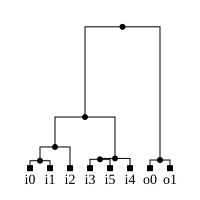

In [1]:
import ancestree as anc
import tskit

ts = tskit.load("quickstart.trees")
tree = anc.TskitLocalTree(
    ts, position=0.0,
    sample_map=anc.TskitLocalTree.sample_map_from_individuals(ts),
)
tree.time_scale = 1e-5  # keeps mu*t below saturation
tree.draw_svg(time_scale="time")


## Two diagnostic sites

The two sites are chosen to separate the models along the axis each one
parametrises. At the first the ingroup is split between `A` and `G`, a transition,
and at the second between `A` and `C`, a transversion. Both outgroups carry `A` in either
case, so the ancestral state itself is not in doubt, and the models differ only
in how much posterior mass they leave on the alternatives.

In [2]:
def split(pos, alt):
    """Ingroup split three-three, both outgroups at the major allele A."""
    tips = {f"i{i}": (alt if i < 3 else "A") for i in range(6)}
    return anc.Site(chrom="chr1", pos=pos, alleles=("A", alt),
                   tip_alleles={**tips, "o0": "A", "o1": "A"})

sites = [split(1, "G"), split(2, "C")]  # transition, transversion


## Posteriors under each model

We call the
{class}`~ancestree.likelihood.Likelihood` kernel directly and combine its
per-root log-likelihood with a {class}`~ancestree.priors.StationaryPrior`. {class}`~ancestree.models.GTR` is omitted, as two sites give no basis for
choosing its six exchangeabilities. An AT-rich `pi` and a `kappa` of 4 are used throughout, values
chosen to keep the four rows distinguishable on sites as simple as these.

In [3]:
at_rich = anc.BaseComposition.from_counts(A=300, C=200, G=200, T=300)
uniform = anc.BaseComposition.from_counts(A=250, C=250, G=250, T=250)
models = [("JC69", anc.JC69(), uniform), ("K2(k=4)", anc.K2(kappa=4.0), uniform),
          ("F81(AT-rich)", anc.F81(), at_rich), ("HKY(k=4, AT-rich)", anc.HKY(kappa=4.0), at_rich)]

print(f"{'site':<14}{'model':<20}" + "".join(f"{b:>8}" for b in "ACGT"))
for site, label in zip(sites, ("transition", "transversion")):
    for name, model, bc in models:
        post = anc.Likelihood(model, base_composition=bc).posterior(tree, site)
        print(f"{label:<14}{name:<20}" + "".join(f"{x:8.4f}" for x in post.values))


site          model                      A       C       G       T
transition    JC69                  0.8387  0.0181  0.1250  0.0181
transition    K2(k=4)               0.7877  0.0040  0.2043  0.0040
transition    F81(AT-rich)          0.8223  0.0165  0.1364  0.0248
transition    HKY(k=4, AT-rich)     0.7786  0.0036  0.2123  0.0055
transversion  JC69                  0.8387  0.1250  0.0181  0.0181
transversion  K2(k=4)               0.8682  0.0729  0.0437  0.0152
transversion  F81(AT-rich)          0.8223  0.1364  0.0165  0.0248
transversion  HKY(k=4, AT-rich)     0.8607  0.0783  0.0400  0.0210


In [4]:
for site in sites:
    for _, model, bc in models:
        assert anc.Likelihood(model, base_composition=bc).posterior(tree, site).map_allele == "A"


## Empirical parameters

Selecting `pi` and `kappa` by hand is rarely appropriate on real data.
{meth}`BaseComposition.from_polymorphic_sites() <ancestree.sites.BaseComposition.from_polymorphic_sites>`
estimates both from the site data in a single pass, and the resulting
{class}`~ancestree.sites.BaseComposition` is what the inference then consumes.
The estimate below is taken over the full quickstart panel.

In [5]:
bc = anc.BaseComposition.from_polymorphic_sites(anc.TskitSource(ts))
print(f"pi = {tuple(round(float(x), 3) for x in bc.pi)}, kappa = {bc.kappa_estimate:.3f}")
anc.HKY(kappa=bc.kappa_estimate)


INFO:ancestree.TskitSource: Reading variants from a tree sequence (224 sites, 8 samples)


pi = (0.248, 0.22, 0.246, 0.285), kappa = 1.177


HKY(kappa=1.177)

In [6]:
assert bc.kappa_estimate > 1.0
